In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### Load the dataset

- fetch_california_housing

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
cal = fetch_california_housing()

In [4]:
cal.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

## Preparing dataset

- Prepare dataset (use target and data)
- Check missing value

- **EDA(Explotary Data Analysis)**
- **Check multi-colinearity,**
     - if two independent data has very high colinearity, we can remove one

- Independend and dependent features
- Split the dataset, (train and test)
- Standarize the data, StandardScaler

In [5]:
dataset = pd.DataFrame(cal.data, columns=cal.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
dataset['Price'] = cal.target
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
# checking missing value
dataset.isnull()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False


## Analyzing correlated feature

In [10]:
# EDA
#Correlation
dataset.corr()

# more the value is towards the +1, more correlated it is.
# more towards the -1, less correlated it is.



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


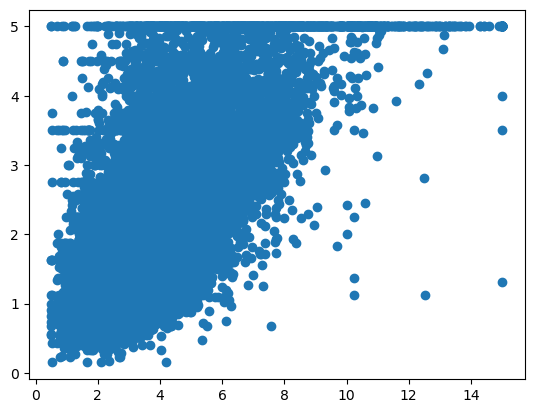

In [11]:
plt.scatter(dataset['MedInc'], dataset['Price'])

<Axes: xlabel='Population', ylabel='Price'>

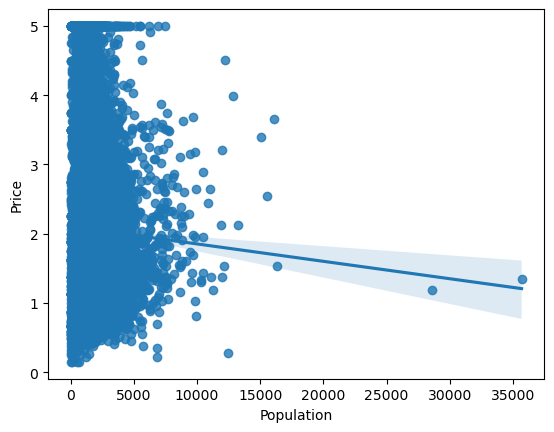

In [12]:
import seaborn as sns
sns.regplot(x = "Population", y = "Price", data = dataset)

In [13]:
## Independent and dependent features

X = dataset.iloc[:, :-1] # independent
y = dataset.iloc[:, -1] # dependent

In [14]:
## Split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y)

In [15]:
## Standarize the dataset

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
import pickle
pickle.dump(scaler, open("scaling.pkl", "wb"))

# Model Training

In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)
preds = model.predict(X_test)

18996    0.606200
15676   -0.611226
11078    0.088610
2524    -0.063280
8802     0.533847
           ...   
18778    0.099640
16094   -0.211730
4984    -0.253740
16927    0.439580
14716   -0.173541
Name: Price, Length: 5160, dtype: float64


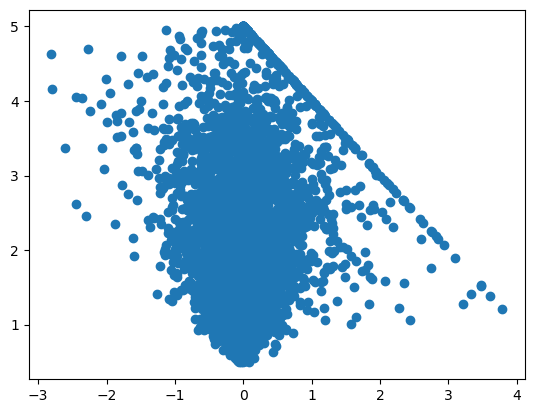

In [18]:
#residual, finding error
residual = y_test - preds
print(residual)

# this should not make any shape.
plt.scatter(residual, preds)


## metrics

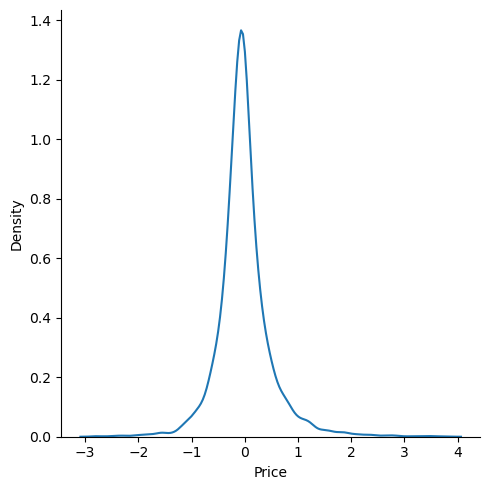

In [19]:
sns.displot(residual, kind = "kde")

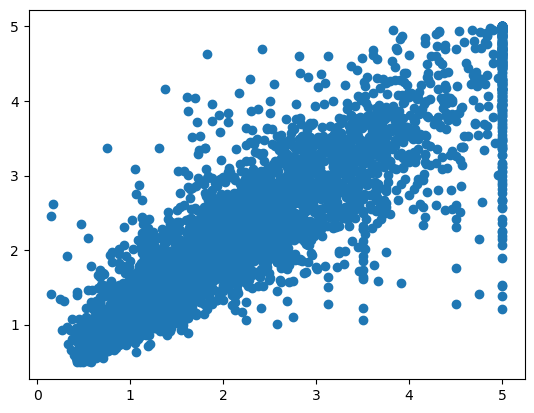

In [20]:

# this shows the colinearity between actual value and predicted value
plt.scatter(y_test , preds)

## R2 and adjusted r2

- r2

      it explain how well does model explain the variability in the target varaible.
      1 being the perfect
      0 being the avg
      -ve being worst


- adjusted r2

      adjusted r2 should be smaller than r2,
      But if the difference is higher, it shows there are some unnecessary features


In [21]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, preds)

print("R2", r2)

R2 0.8007342295111306


In [22]:
#adjusted r2, should be less than r2
1 - (1-r2)* (len(y_test)-1) / (len(y_test)-X_test.shape[1]-1)

0.8004247505431805

## New data prediction

In [23]:
import pandas as pd

new_data = cal.data[0].reshape(1,-1)
new_data

array([[   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]])

In [24]:
## standarize
new_data = scaler.transform(new_data)

/home/sauhardha-kafle/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [25]:
print(y.min(), y.max())
print(y.mean())

0.14999 5.00001
2.068558169089147


In [26]:
new_pred = model.predict(new_data)
new_pred

array([4.4014307])

## Picking the Model File for deployment

In [27]:
import pickle as pkl

pkl.dump(model, open("housingmodel.pkl", "wb"))

In [28]:
pickled_model = pkl.load(open("housingmodel.pkl", "rb"))

In [29]:
pickled_model.predict(new_data)

array([4.4014307])

## Linear Regression model (below)

-------


In [30]:
# from sklearn.linear_model import LinearRegression

# regression = LinearRegression()
# regression.fit(X_train, y_train)

In [31]:
# it tells, how much does the house price(target) changes with the change in the feature by 1
# print(regression.coef_)

In [32]:
# baseline value of house, when all the features value is 0
# print(regression.intercept_)

In [33]:
# regression.get_params()

In [34]:
# prediction with the test_data
# reg_pred = regression.predict(X_test)

In [35]:
# reg_pred

In [36]:
## plot a scatter plot for the prediction

# this shows colinearity
# plt.scatter(y_test, reg_pred)

In [37]:
# residuals is error.
# residuals = y_test - reg_pred
# residuals

In [38]:
# sns.displot(residuals, kind="kde")

In [39]:
## scatter plot with respect to prediction and residuals

# this should be uniform distributed and should not make any shape.
# plt.scatter(reg_pred, residuals)

In [40]:
# plt.scatter(y_test, reg_pred)
# plt.xlabel("Actual prices")
# plt.ylabel("Predicted prices")
# plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Perfect line

In [41]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# print("MAE:", mean_absolute_error(y_test, reg_pred))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, reg_pred)))
# print("R² Score:", r2_score(y_test, reg_pred))

In [42]:
# metrics
# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import mean_absolute_error

# # mean_absolute_error, the difference between prediction and actual value
# print(mean_absolute_error(y_test, reg_pred))

# # mean_squared_error, average of squared difference between actual and predicted value
# print(mean_squared_error(y_test, reg_pred))

# # this brings MSE back to the original units of the target (like dollars if predicting price)
# print(np.sqrt(mean_squared_error(y_test, reg_pred)))

# R squared and adjusted R square

Formula,

**R^2 = 1 - SSR/SST**

**SSR**: Sum of Squares of Residual
**SST**: Total Sum of Squares.

<br>


In [43]:
# from sklearn.metrics import r2_score
# scorer = r2_score(y_test, reg_pred)
# print(scorer)

<br>

*Adjusted R^2 will always less than R^2*

**Adjusted R^2 = 1-[(1-R^2)*(n-1)/(n-k-1)]**

In [44]:
# 1 - (1- scorer)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

In [45]:
# feature_importance = pd.Series(regression.coef_, index = X.columns)
# feature_importance.sort_values(ascending = False).plot(kind='bar')